In [36]:
!pip install pytorch-lightning


     ---------------------------------------- 0.0/77.6 kB ? eta -:--:--
     ---------------------------------------- 77.6/77.6 kB 4.2 MB/s eta 0:00:00
   ---------------------------------------- 0.0/831.6 kB ? eta -:--:--
   --------------------- ------------------ 450.6/831.6 kB 9.6 MB/s eta 0:00:01
   --------------------------------------- 831.6/831.6 kB 10.5 MB/s eta 0:00:00
   ---------------------------------------- 0.0/158.8 kB ? eta -:--:--
   ---------------------------------------- 158.8/158.8 kB 9.3 MB/s eta 0:00:00
   ---------------------------------------- 0.0/983.2 kB ? eta -:--:--
   ------------------ -------------------- 471.0/983.2 kB 14.9 MB/s eta 0:00:01
   --------------------------------------  983.0/983.2 kB 12.5 MB/s eta 0:00:01
   --------------------------------------- 983.2/983.2 kB 10.4 MB/s eta 0:00:00
   ---------------------------------------- 0.0/456.2 kB ? eta -:--:--
   --------------------------------------- 456.2/456.2 kB 14.4 MB/s eta 0:00:00
   -


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [37]:
import random
import numpy as np
import torch
import pytorch_lightning as pl

seed = 0
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
pl.seed_everything(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

Seed set to 0


In [38]:
# === Importing the dependencies ===
import os
import json
from zipfile import ZipFile
from PIL import Image

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
import torchvision.transforms as transforms
import torchvision.datasets as datasets

In [39]:
kaggle_credentials= json.load(open(r"C:\Users\RITAM\Desktop\PROJECT 3\MODEL TRAINING NOTEBOOK\kaggle.json"))

In [41]:
# Setup Kaggle API key as environment variables
os.environ['KAGGLE_USERNAME'] = kaggle_credentials["username"]
os.environ['KAGGLE_KEY'] = kaggle_credentials["key"]

In [42]:
os.system("kaggle datasets download -d abdallahalidev/plantvillage-dataset")

0

In [43]:
print("Unzipping dataset...")
with ZipFile("plantvillage-dataset.zip", 'r') as zip_ref:
    zip_ref.extractall()

Unzipping dataset...


Exception ignored in: <function tqdm.__del__ at 0x0000018E8F3F11C0>
Traceback (most recent call last):
  File "c:\Users\RITAM\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\std.py", line 1148, in __del__
    self.close()
  File "c:\Users\RITAM\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\notebook.py", line 279, in close
    self.disp(bar_style='danger', check_delay=False)
    ^^^^^^^^^
AttributeError: 'tqdm_notebook' object has no attribute 'disp'
Exception ignored in: <function tqdm.__del__ at 0x0000018E8F3F11C0>
Traceback (most recent call last):
  File "c:\Users\RITAM\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\std.py", line 1148, in __del__
    self.close()
  File "c:\Users\RITAM\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\notebook.py", line 279, in close
    self.disp(bar_style='danger', check_delay=False)
    ^^^^^^^^^
AttributeError: 'tqdm_notebook' object has no attribute 'disp'


In [44]:
# --- 3. Explore Dataset ---
print(os.listdir("plantvillage dataset"))
print(f"Color images found: {len(os.listdir('plantvillage dataset/color'))} classes")
print(f"Sample classes: {os.listdir('plantvillage dataset/color')[:5]}")
print(f"Total classes = 38")

['color', 'grayscale', 'segmented']
Color images found: 38 classes
Sample classes: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']
Total classes = 38


In [46]:
# --- 4. Define Paths and Parameters ---
base_dir = 'plantvillage dataset/color'
img_size = 224
batch_size = 32

In [66]:
class PlantDataModule(pl.LightningDataModule):
    """
    A LightningDataModule encapsulates all the steps needed to
    process data: downloading, splitting, transforming, and loading.
    """
    def __init__(self, data_dir, batch_size, img_size):
        super().__init__()
        self.data_dir = data_dir
        self.batch_size = batch_size
        self.img_size = img_size
        
        # Define the transformations (preprocessing steps)
        # 1. Resize: All images must be the same size.
        # 2. ToTensor: Converts PIL Image to PyTorch tensor and scales [0, 255] to [0.0, 1.0].
        # 3. Normalize: Standard for ImageNet models. Helps with faster convergence.
        self.transform = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

    def setup(self, stage=None):
        # 1. Load the full dataset from the directory
        full_dataset = datasets.ImageFolder(self.data_dir, transform=self.transform)
        
        # 2. Store class names and index map
        self.class_names = full_dataset.classes
        self.class_indices_map = full_dataset.class_to_idx
        self.num_classes = len(self.class_names)
        
        # 3. Split the dataset (80% train, 20% validation)
        train_size = int(0.8 * len(full_dataset))
        val_size = len(full_dataset) - train_size
        self.train_dataset, self.val_dataset = random_split(full_dataset, [train_size, val_size])

    def train_dataloader(self):
        # Creates the loader for the training set
        # num_workers > 0 speeds up loading by using subprocesses
        return DataLoader(self.train_dataset, batch_size=self.batch_size, shuffle=True, num_workers=4, persistent_workers=True)

    def val_dataloader(self):
        # Creates the loader for the validation set
        return DataLoader(self.val_dataset, batch_size=self.batch_size, shuffle=False, num_workers=4, persistent_workers=True)

# Initialize the DataModule
dm = PlantDataModule(data_dir=base_dir, batch_size=batch_size, img_size=img_size)
dm.setup() # Call setup to get num_classes and class_names
print(f"Data setup complete. Found {dm.num_classes} classes.")

Data setup complete. Found 38 classes.


In [76]:
# Instantiate the model
model = LitCNNModel(num_classes=dm.num_classes)
print("Model Architecture:")
print(model)

Model Architecture:
LitCNNModel(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=186624, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=38, bias=True)
)


In [77]:
# Model Definition as a LightningModule (Corrected)
class LitCNNModel(pl.LightningModule):
    def __init__(self, num_classes):
        super().__init__()
        self.num_classes = num_classes
        
        # --- Model Architecture ---
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.flatten = nn.Flatten()
        # Flattened size: 64 * 54 * 54 = 186624
        self.fc1 = nn.Linear(64 * 54 * 54, 256)
        self.fc2 = nn.Linear(256, self.num_classes)
        
        # --- History Tracking (for plots) ---
        self.history = {'accuracy': [], 'val_accuracy': [], 'loss': [], 'val_loss': []}

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool1(x)
        x = F.relu(self.conv2(x))
        x = self.pool2(x)
        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

    # --- Logic for one training batch ---
    def training_step(self, batch, batch_idx):
        inputs, labels = batch
        outputs = self(inputs) 
        loss = F.cross_entropy(outputs, labels) 
        
        preds = torch.argmax(outputs, dim=1)
        acc = (preds == labels).float().mean() 
        
        self.log('train_loss', loss, on_step=True, on_epoch=True, prog_bar=True, logger=True)
        self.log('train_accuracy', acc, on_step=False, on_epoch=True, prog_bar=True, logger=True)
        return loss

    # --- Logic for one validation batch ---
    def validation_step(self, batch, batch_idx):
        inputs, labels = batch
        outputs = self(inputs)
        loss = F.cross_entropy(outputs, labels)
        
        preds = torch.argmax(outputs, dim=1)
        acc = (preds == labels).float().mean()
        
        self.log('val_loss', loss, on_epoch=True, prog_bar=True, logger=True)
        self.log('val_accuracy', acc, on_epoch=True, prog_bar=True, logger=True)
        return loss
    
    # --- Store training results at the END of the training epoch ---
    def on_train_epoch_end(self):
        # Don't log metrics from the sanity check
        if self.trainer.sanity_checking:
            return
        
        # *** THIS IS THE FIX: ***
        # The key is 'train_accuracy', not 'train_accuracy_epoch'
        # because we set on_step=False
        train_loss = self.trainer.logged_metrics['train_loss_epoch'].item()
        train_acc = self.trainer.logged_metrics['train_accuracy'].item() 
        
        self.history['loss'].append(train_loss)
        self.history['accuracy'].append(train_acc)

    # --- Store validation results at the END of the validation epoch ---
    def on_validation_epoch_end(self):
        # Don't log metrics from the sanity check
        if self.trainer.sanity_checking:
            return
            
        val_loss = self.trainer.logged_metrics['val_loss'].item()
        val_acc = self.trainer.logged_metrics['val_accuracy'].item()
        self.history['val_loss'].append(val_loss)
        self.history['val_accuracy'].append(val_acc)
        
    # --- Define the optimizer (like model.compile()) ---
    def configure_optimizers(self):
        optimizer = optim.Adam(self.parameters(), lr=0.001)
        return optimizer

# Instantiate the model
model = LitCNNModel(num_classes=dm.num_classes)
print("Model Architecture:")
print(model)

Model Architecture:
LitCNNModel(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=186624, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=38, bias=True)
)


In [78]:
# === 7. Model Training ===
print("\nStarting model training...")

# Initialize the Lightning Trainer
# This object handles the training loop, GPU/CPU placement, and progress bar
trainer = pl.Trainer(
    max_epochs=5,                 # Same as epochs=5
    accelerator="auto",         # Automatically uses "cuda" if available
    callbacks=[pl.callbacks.TQDMProgressBar(refresh_rate=10)] # Creates the Keras-style bar
)

# --- Start Training! ---
# This is the equivalent of Keras's model.fit()
# It will show the live, single-line progress bar.
trainer.fit(model, dm)

print("Training Complete")

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.



Starting model training...


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name    | Type      | Params | Mode 
----------------------------------------------
0 | conv1   | Conv2d    | 896    | train
1 | pool1   | MaxPool2d | 0      | train
2 | conv2   | Conv2d    | 18.5 K | train
3 | pool2   | MaxPool2d | 0      | train
4 | flatten | Flatten   | 0      | train
5 | fc1     | Linear    | 47.8 M | train
6 | fc2     | Linear    | 9.8 K  | train
----------------------------------------------
47.8 M    Trainable params
0         Non-trainable params
47.8 M    Total params
191.221   Total estimated model params size (MB)
7         Modules in train mode
0         Modules in eval mode


Epoch 4: 100%|██████████| 1358/1358 [03:02<00:00,  7.43it/s, v_num=3, train_loss_step=0.0698, val_loss=0.561, val_accuracy=0.877, train_loss_epoch=0.085, train_accuracy=0.974]  

`Trainer.fit` stopped: `max_epochs=5` reached.


Epoch 4: 100%|██████████| 1358/1358 [03:11<00:00,  7.08it/s, v_num=3, train_loss_step=0.0698, val_loss=0.561, val_accuracy=0.877, train_loss_epoch=0.085, train_accuracy=0.974]
Training Complete



Final Validation Accuracy: 87.68%


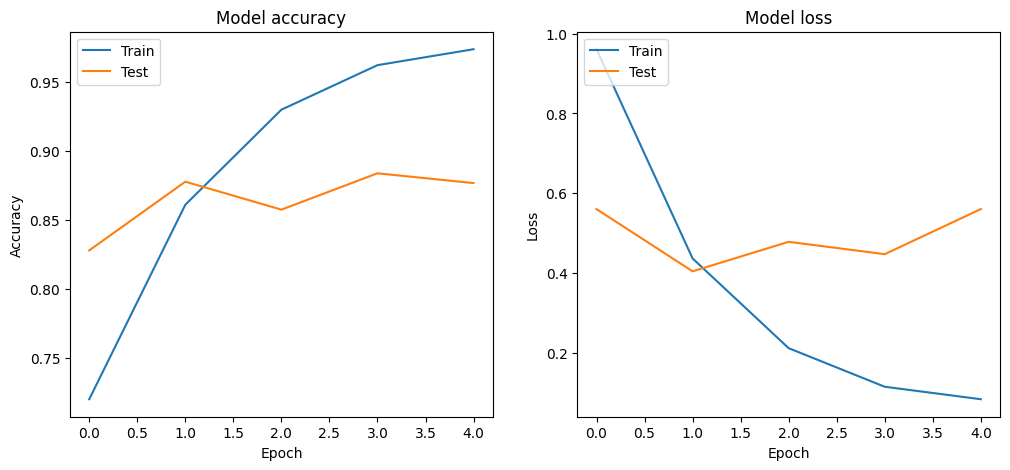

In [87]:
# Get history from the model object
history = model.history

print(f"\nFinal Validation Accuracy: {history['val_accuracy'][-1] * 100:.2f}%")

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history['accuracy'])
plt.plot(history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history['loss'])
plt.plot(history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

In [88]:
def load_and_preprocess_image(image_path, target_size=(224, 224)):
    """Loads, resizes, and preprocesses a single image for prediction."""
    preprocess = transforms.Compose([
        transforms.Resize(target_size),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    img = Image.open(image_path).convert('RGB')
    img_tensor = preprocess(img)
    img_tensor = img_tensor.unsqueeze(0) # Add batch dimension [1, 3, 224, 224]
    return img_tensor

def predict_image_class(model, image_path, class_names):
    """Runs a prediction on a single image file."""
    preprocessed_img = load_and_preprocess_image(image_path)
    preprocessed_img = preprocessed_img.to(model.device) # Move image to model's device
    
    model.eval() # Set model to evaluation mode
    with torch.no_grad(): # Disable gradient calculation
        outputs = model(preprocessed_img)
        probabilities = F.softmax(outputs, dim=1)
        _, predicted_index = torch.max(probabilities, 1)
        
    predicted_class_index = predicted_index.item()
    predicted_class_name = class_names[predicted_class_index]
    return predicted_class_name

# Get class names and index map from the DataModule
class_names = dm.class_names
class_indices_map = dm.class_indices_map

# Save the class name-to-index mapping
json.dump(class_indices_map, open('class_indices.json', 'w'))

In [94]:
# Example Usage
print("Running predictions on your local test images...")

# Get class names from the DataModule (make sure 'dm' is defined from Step 5)
class_names = dm.class_names

# Use the file paths you provided
# Note: The 'r' before the string is important for Windows paths
image_path1 = r'C:\Users\RITAM\Desktop\PROJECT 3\test_images\test_apple_black_rot.JPG'
image_path2 = r'C:\Users\RITAM\Desktop\PROJECT 3\test_images\test_blueberry_healthy.jpg'
image_path3 = r'C:\Users\RITAM\Desktop\PROJECT 3\test_images\test_potato_early_blight.jpg'

try:
    predicted_class_name1 = predict_image_class(model, image_path1, class_names)
    print(f"Predicted Class Name for Image 1 ({image_path1}): {predicted_class_name1}")
    
    predicted_class_name2 = predict_image_class(model, image_path2, class_names)
    print(f"Predicted Class Name for Image 2 ({image_path2}): {predicted_class_name2}")
    
    predicted_class_name3 = predict_image_class(model, image_path3, class_names)
    print(f"Predicted Class Name for Image 3 ({image_path3}): {predicted_class_name3}")

except FileNotFoundError as e:
    print(f"\nError: {e}")
    print("One of the image files was not found. Please double-check your file paths.")
except NameError as e:
    print(f"\nError: {e}")
    print("Make sure you have run the cells defining 'dm', 'model', and 'predict_image_class'.")

Running predictions on your local test images...
Predicted Class Name for Image 1 (C:\Users\RITAM\Desktop\PROJECT 3\test_images\test_apple_black_rot.JPG): Apple___Black_rot
Predicted Class Name for Image 2 (C:\Users\RITAM\Desktop\PROJECT 3\test_images\test_blueberry_healthy.jpg): Blueberry___healthy
Predicted Class Name for Image 3 (C:\Users\RITAM\Desktop\PROJECT 3\test_images\test_potato_early_blight.jpg): Potato___Early_blight


In [93]:
# Save the model state dictionary (the learned weights)
print("\nSaving model...")
torch.save(model.state_dict(), 'plant_disease_prediction_model.pth')
print("Model saved as 'plant_disease_prediction_model.pth'")


Saving model...
Model saved as 'plant_disease_prediction_model.pth'
